In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def filter_split(df: pd.DataFrame, split: str = "train", split_col: str = "split") -> pd.DataFrame:
    if split_col in df.columns:
        return df[df[split_col].astype(str).str.lower() == split.lower()].copy()
    return df.copy()

def plot_domain_bar_topN(
    df: pd.DataFrame,
    domain_col: str = "domain",
    top_n: int = 20,
    title: str = "",
    outpath: str = "domain_bar_topN.pdf",  # PDF statt PNG
    figsize=(10, 6),
) -> None:
    counts = df[domain_col].value_counts(dropna=False)
    top = counts.head(top_n)
    other_count = counts.iloc[top_n:].sum()
    if other_count > 0:
        top = pd.concat([top, pd.Series({"Other": other_count})])

    plt.figure(figsize=figsize)
    top.sort_values(ascending=False).plot(kind="bar")
    plt.title(title)
    plt.xlabel("Domain")
    plt.ylabel("Number of claims")
    plt.yscale("log")  # Log-Skala
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(outpath, format="pdf", bbox_inches="tight")  # Vektorgrafik
    plt.close()

def plot_claims_per_domain_hist(
    df: pd.DataFrame,
    domain_col: str = "domain",
    bins: int = 30,
    title: str = "Claims per domain (histogram)",
    outpath: str = "claims_per_domain_hist.pdf",  # PDF statt PNG
    figsize=(8, 5),
    log_x: bool = False
) -> None:
    per_domain = df.groupby(domain_col).size()

    plt.figure(figsize=figsize)
    plt.hist(per_domain.values, bins=bins)
    plt.title(title)
    plt.xlabel("Number of claims in domain")
    plt.ylabel("Number of domains")
    if log_x:
        plt.xscale("log")
        plt.xlabel("Number of claims in domain")
    plt.tight_layout()
    plt.savefig(outpath, format="pdf", bbox_inches="tight")  # Vektorgrafik
    plt.close()

# -------------------------
# Example usage
# -------------------------
df_train = pd.read_csv("../Datasets/LIAR/train_cleaned.csv")
os.makedirs("figures", exist_ok=True)

plot_domain_bar_topN(
    df_train,
    domain_col="subjects",
    top_n=20,
    outpath="figures/liar_domains_top20_train.pdf"
)

plot_claims_per_domain_hist(
    df_train,
    domain_col="subjects",
    bins=30,
    title="Number of claims per domain (training set)",
    outpath="figures/liar_claims_per_domain_hist_train.pdf",
    log_x=True
)

In [14]:
def plot_binary_label_distribution(
    df: pd.DataFrame,
    label_col: str = "label",
    outpath: str = "figures/label_distribution_binary_train.pdf",
    figsize=(5, 4)
) -> None:
    # Binary mapping
    false_labels = ["false", "barely-true", "pants-fire"]
    true_labels = ["true", "mostly-true", "half-true"]
    
    df = df.copy()
    df["binary_label"] = df[label_col].apply(
        lambda x: "false" if x in false_labels else "true"
    )
    
    counts = df["binary_label"].value_counts()
    
    plt.figure(figsize=figsize)
    bars = plt.bar(counts.index, counts.values, color=["steelblue", "salmon"])
    
    for bar, count in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            str(count),
            ha="center", va="bottom", fontsize=10
        )
    
    plt.xlabel("Label")
    plt.ylabel("Number of claims")
    plt.tight_layout()
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.close()

# Aufruf
plot_binary_label_distribution(
    df_train,
    label_col="label",
    outpath="figures/label_distribution_binary_train.pdf"
)

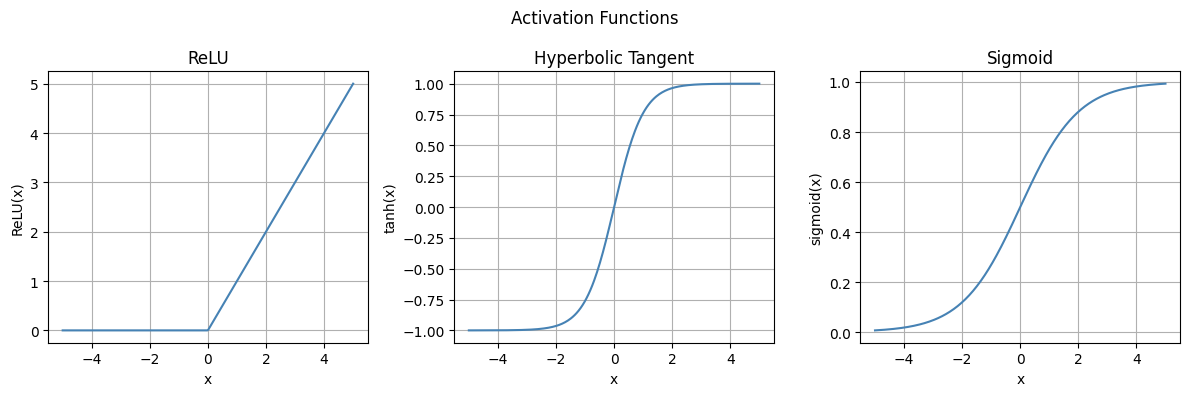

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)

# Aktivierungsfunktionen
relu = np.maximum(0, x)
tanh = np.tanh(x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(x, relu, color='steelblue')
axes[0].set_title('ReLU')
axes[0].set_xlabel('x')
axes[0].set_ylabel('ReLU(x)')
axes[0].grid(True)

axes[1].plot(x, tanh, color='steelblue')
axes[1].set_title('Hyperbolic Tangent')
axes[1].set_xlabel('x')
axes[1].set_ylabel('tanh(x)')
axes[1].grid(True)

axes[2].plot(x, sigmoid, color='steelblue')
axes[2].set_title('Sigmoid')
axes[2].set_xlabel('x')
axes[2].set_ylabel('sigmoid(x)')
axes[2].grid(True)

fig.suptitle('Activation Functions')
plt.tight_layout()

# Als Vektorgrafik speichern
plt.savefig('activation_functions.pdf', bbox_inches='tight')
plt.show()